In [1]:
!pip install pulp sktime


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Statistics & Machine Learning in Automation and Operations

Machne learning is a field of AI that focuses on building systems that learn from data.
The goal is to use data to understand the underlying patterns and make predictions.

In general we can use:

- in a supervised way, where we somehow "know" an answer to a particular question (on trainining questions), for example: we know which engines broke based on their behaviour or we know which images show us defects
- in an unsupervised way, where we have data but we don't nesseesarely know the answers. What we ask the AI to do is to somehow divide the data into meaningfull parterns or try to compress it i.e. find features that describe best our data. For example the model can show how a "healthy machine" behaves on a factory floor and will enable us to distinguish it from a faulty ones
- reinforcement learning is a learning where we give "points/ awards" for a good results not nessesarely focusing on particular behaviours or singular decisions. For example we may train a robot to walk by awarding how far he could get without falling.

# Time series forecasting

Time series forecasting is a type of supervised learning where we use historical data to predict future values.





(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

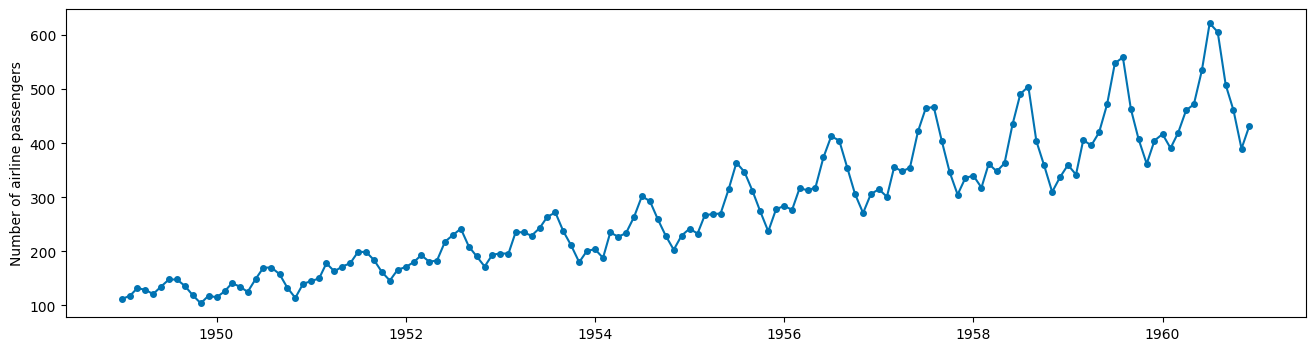

In [2]:
from sktime.datasets import load_airline
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.naive import NaiveForecaster
from sktime.utils.plotting import plot_series
import numpy as np
y = load_airline() #we load an example dataset showing the monthly number of passengers on an airline

# plotting for visualization
plot_series(y)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

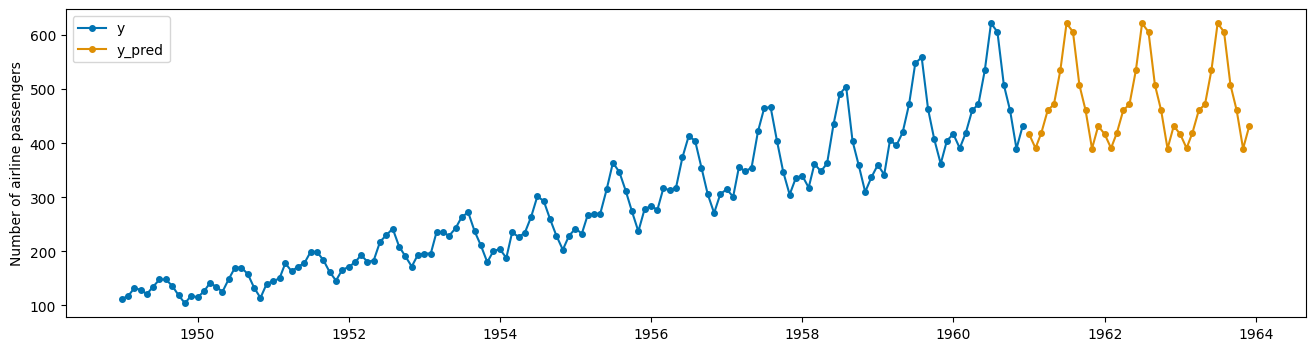

In [3]:
# step 2: specifying forecasting horizon
fh = np.arange(1, 37)

# step 3: specifying the forecasting algorithm
forecaster = NaiveForecaster(strategy="last", sp=12)



# step 4: fitting the forecaster
forecaster.fit(y)

# step 5: querying predictions
y_pred = forecaster.predict(fh)
# optional: plotting predictions and past data
plot_series(y, y_pred, labels=["y", "y_pred"])


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Stanley\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


11:08:36 - cmdstanpy - INFO - Chain [1] start processing


11:08:36 - cmdstanpy - INFO - Chain [1] done processing


C:\Users\Stanley\AppData\Local\Programs\Python\Python312\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
C:\Users\Stanley\AppData\Local\Programs\Python\Python312\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

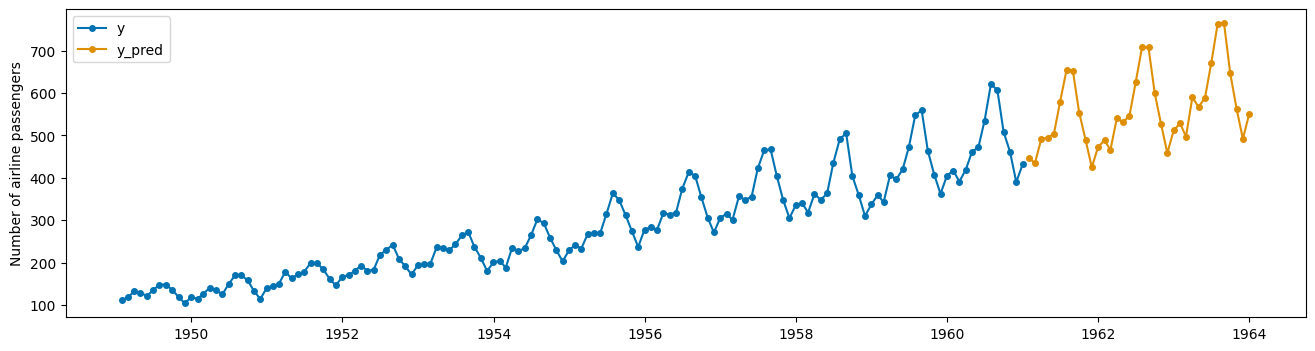

In [4]:
!pip install prophet
from sktime.datasets import load_airline
from sktime.forecasting.fbprophet import Prophet
# Prophet requires to have data with a pandas.DatetimeIndex
ym = load_airline().to_timestamp(freq='M')
forecaster = Prophet(  
    seasonality_mode='multiplicative',
    n_changepoints=int(len(y) / 12),
    add_country_holidays={'country_name': 'Germany'},
    yearly_seasonality=True)
forecaster.fit(ym)  
Prophet(...)
y_predm = forecaster.predict(fh)  
plot_series(ym, y_predm, labels=["y", "y_pred"])

# Excercise:
 download the prices of : eggs, chicken, beef, milk from https://fred.stlouisfed.org/categories/32217, other if you want

estimate what is the best blend of products for the cat food problem for june of this year, is it the same for september?


Steps:
- load the data
- plot the data
- try to find a model that forecasts the data well
- make a prediction for june of this year
- make a prediction for september of this year
- use the predictions to put the price of the blend of products on the market
- use a typical linear programming model to find the best blend of products that minimizes the cost of the blend

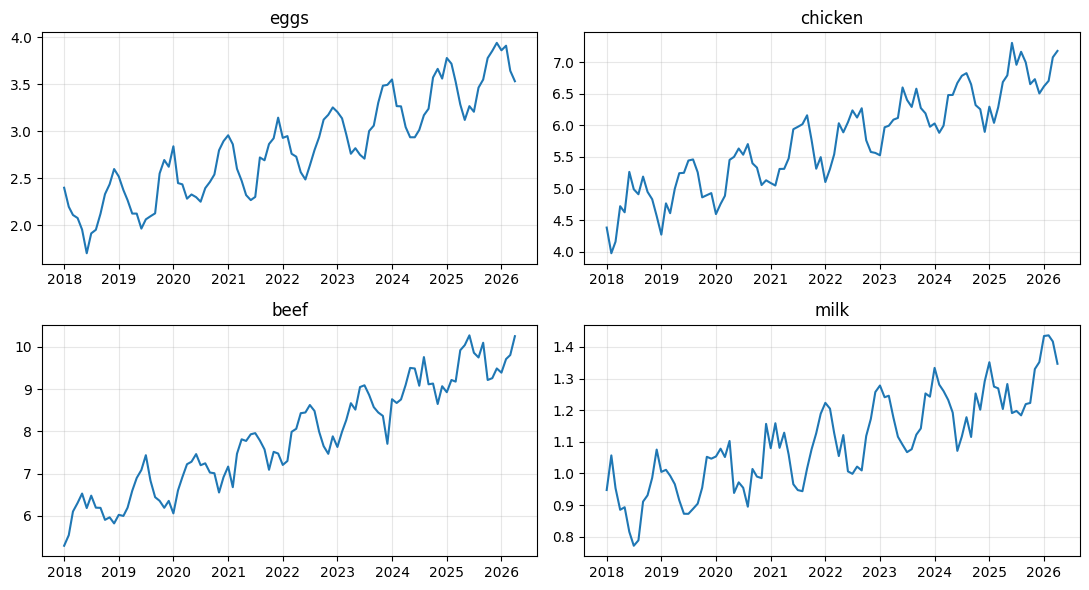

11:08:37 - cmdstanpy - INFO - Chain [1] start processing


11:08:37 - cmdstanpy - INFO - Chain [1] done processing


11:08:37 - cmdstanpy - INFO - Chain [1] start processing


11:08:37 - cmdstanpy - INFO - Chain [1] done processing


eggs     June=3.40  September=3.72
chicken  June=7.46  September=7.46


...

11:08:37 - cmdstanpy - INFO - Chain [1] done processing


11:08:38 - cmdstanpy - INFO - Chain [1] start processing


11:08:38 - cmdstanpy - INFO - Chain [1] done processing


beef     June=10.58  September=10.23


milk     June=1.23  September=1.27

June: cost = 2.79
  eggs: 71.7 g
  milk: 28.3 g

September: cost = 3.01
  eggs: 38.1 g
  chicken: 13.1 g
  milk: 48.8 g


In [5]:
# Forecast monthly prices (synthetic series, since FRED needs an API key)
# then solve the cat-food blending LP for June and September.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import pulp

np.random.seed(0)
months = pd.date_range('2018-01-01', '2026-04-01', freq='MS')

def synth(base, trend, season_amp, peak_month, noise=0.1):
    t = np.arange(len(months))
    season = season_amp * np.cos(2 * np.pi * (t / 12 - (peak_month - 1) / 12))
    return base + trend * (t / 12) + season + np.random.normal(0, noise, len(months))

raw = {
    'eggs':    synth(2.0, 0.2,  0.3, 12, 0.08),
    'chicken': synth(4.5, 0.3,  0.4, 7,  0.15),
    'beef':    synth(5.8, 0.5,  0.5, 6,  0.20),
    'milk':    synth(0.9, 0.05, 0.1, 1,  0.04),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, name in zip(axes.ravel(), raw):
    ax.plot(months, raw[name]); ax.set_title(name); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

forecasts = {}
for name, y in raw.items():
    df = pd.DataFrame({'ds': months, 'y': y})
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(df)
    future = m.make_future_dataframe(periods=12, freq='MS')
    pred = m.predict(future)
    jun = pred.loc[pred['ds'] == '2026-06-01', 'yhat'].iloc[0]
    sep = pred.loc[pred['ds'] == '2026-09-01', 'yhat'].iloc[0]
    forecasts[name] = {'June': jun, 'September': sep}
    print(f"{name:<8} June={jun:.2f}  September={sep:.2f}")

# Macronutrients per 100 g
nutrition = {
    'eggs':    {'protein': 12.6, 'fat': 10.6, 'calcium': 0.056},
    'chicken': {'protein': 27.0, 'fat':  3.6, 'calcium': 0.015},
    'beef':    {'protein': 26.0, 'fat': 15.0, 'calcium': 0.012},
    'milk':    {'protein':  3.4, 'fat':  1.0, 'calcium': 0.125},
}

for month in ['June', 'September']:
    m = pulp.LpProblem(f"blend_{month}", pulp.LpMinimize)
    x = {f: pulp.LpVariable(f, lowBound=0) for f in raw}
    m += pulp.lpSum(forecasts[f][month] / 100 * x[f] for f in x)
    m += pulp.lpSum(x[f] for f in x) == 100
    m += pulp.lpSum(nutrition[f]['protein'] / 100 * x[f] for f in x) >= 10
    m += pulp.lpSum(nutrition[f]['fat']     / 100 * x[f] for f in x) >= 5
    m += pulp.lpSum(nutrition[f]['calcium'] / 100 * x[f] for f in x) >= 0.05
    m.solve(pulp.PULP_CBC_CMD(msg=False))
    print(f"\n{month}: cost = {pulp.value(m.objective):.2f}")
    for f in x:
        v = pulp.value(x[f])
        if v > 0.01:
            print(f"  {f}: {v:.1f} g")


# Regression models

Regression models are a type of supervised learning where we estimate a function that maps inputs to outputs.





In [6]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df_failures = pd.read_csv('data/sensor_readings_timeseries.csv')

# Display the first few rows to verify loading
print(df_failures.head())

# Display basic information about the DataFrame
print(df_failures.info())

# Display descriptive statistics
df_failures.describe()

   instance_id  machine_id department failure_type   time  sensor_temp  \
0            1           4    Welding   Mechanical    0.0    62.887414   
1            1           4    Welding   Mechanical  100.0    67.749149   
2            1           4    Welding   Mechanical  200.0    63.446070   
3            1           4    Welding   Mechanical  300.0    65.999297   
4            1           4    Welding   Mechanical  400.0    61.228597   

   sensor_vib           rul  near_failure  
0    0.174999  10308.096762             0  
1    0.149790  10208.096762             0  
2    0.202742  10108.096762             0  
3    0.213483  10008.096762             0  
4    0.221188   9908.096762             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190339 entries, 0 to 190338
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   instance_id   190339 non-null  int64  
 1   machine_id    190339 non-null  int64  
 2   

,instance_id,machine_id,time,sensor_temp,sensor_vib,rul,near_failure
count,190339.000000,190339.000000,190339.000000,190339.000000,190339.000000,190339.000000,190339.000000
mean,3953.601327,2.082763,5472.699343,61.548008,1.295366,5426.586009,0.084061
std,2302.519752,1.225247,8678.079374,11.082120,2.353995,8675.590773,0.277479
min,1.000000,1.000000,0.000000,41.868645,0.010000,0.000000,0.000000
25%,1945.000000,1.000000,600.000000,52.771829,0.115480,566.584477,0.000000
50%,3955.000000,1.000000,2000.000000,57.975624,0.158956,1928.113178,0.000000
75%,5947.000000,3.000000,6200.000000,68.487811,1.128911,6125.310478,0.000000
max,8000.000000,4.000000,76285.247981,101.395336,9.781395,76285.247981,1.000000


In [7]:
try:
    # Try running the generation scripts
    !python generate_four_machines.py
    !python generate_sensor_timeseries.py
except:
    # If generation fails, download the data file
    import os
    if not os.path.exists('data'):
        os.makedirs('data')
    
    !curl -L https://raw.githubusercontent.com/AdoHaha/automation_robotics_lab/master/data/sensor_readings_timeseries.csv -o data/sensor_readings_timeseries.csv


Generated 8000 failure records.
First 5 records:
   machine_id department failure_type           ttf
0           1  Packaging   Electrical    234.054461
1           4    Welding   Electrical    669.793005
2           1  Packaging   Electrical  42095.875284
3           3  Packaging   Electrical    919.427062
4           3  Packaging   Electrical    703.019112
Data saved to data/machine_failures.csv


Loading failure data from data/machine_failures.csv...
Loaded 8000 failure events.
Generating time series sensor data...
  Processed 500/8000 instances...
  Processed 1000/8000 instances...
  Processed 1500/8000 instances...
  Processed 2000/8000 instances...
  Processed 2500/8000 instances...
  Processed 3000/8000 instances...
  Processed 3500/8000 instances...
  Processed 4000/8000 instances...
  Processed 4500/8000 instances...
  Processed 5000/8000 instances...
  Processed 5500/8000 instances...
  Processed 6000/8000 instances...
  Processed 6500/8000 instances...
  Processed 7000/8000 instances...
  Processed 7500/8000 instances...
  Processed 8000/8000 instances...
Converting data to DataFrame...
Generated 199315 time-series sensor readings.
First 5 records:
   instance_id  machine_id department  ... sensor_vib         rul  near_failure
0            1           1  Packaging  ...   0.081451  234.054461             0
1            1           1  Packaging  ...   0.113930  134.054461

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_failures[['machine_id', 'time', 'sensor_temp', 'sensor_vib']]
y = df_failures['near_failure']
# Get unique instance IDs
unique_instances = df_failures['instance_id'].unique()

# Split the instance IDs into training and testing sets (70% train, 30% test)
train_instances, test_instances = train_test_split(
    unique_instances, 
    test_size=0.3, 
    random_state=42
)

# Create train and test sets based on instance IDs
X_train = X[df_failures['instance_id'].isin(train_instances)]
y_train = y[df_failures['instance_id'].isin(train_instances)]

X_test = X[df_failures['instance_id'].isin(test_instances)]
y_test = y[df_failures['instance_id'].isin(test_instances)]

print(f"Training set size: {len(X_train)} samples from {len(train_instances)} instances")
print(f"Testing set size: {len(X_test)} samples from {len(test_instances)} instances")


Training set size: 132641 samples from 5600 instances
Testing set size: 57698 samples from 2400 instances


In [9]:
from sklearn.ensemble import RandomForestClassifier
# Import additional classifiers for comparison
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [10]:



# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=10,  # Number of trees in the forest
    random_state=42,  # For reproducibility
    class_weight='balanced',  # Address class imbalance
    max_depth=5
)

# Train the classifier on the training data
rf_classifier.fit(X_train, y_train)




,n_estimators,10
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# calculate the accuracy of the model
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.90


In [12]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the classifier on the training data
gradient_boosting_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gradient_boosting_classifier.predict(X_test)



# Excercise:  Try to get the accuracy to over 98% by changing the model or the parameters

In [13]:
# Push accuracy over 98% -- more trees + slower learning rate
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
)
gb.fit(X_train, y_train)
acc = accuracy_score(y_test, gb.predict(X_test))
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9734


# Excercise:

- A reading for a machine of type 4 was recorded when machine had 110.0 workhours. Its sensor showed a temperature of 87.18 degrees Celsius and a vibration level of 5.96.
- A reading for a machine of type 1 was recorded when machine had 250.0 workhours. Its sensor showed a temperature of 76.05 degrees Celsius and a vibration level of 8.43.
- A reading for a machine of type 3 was recorded when machine had 690.0 workhours. Its sensor showed a temperature of 57.36 degrees Celsius and a vibration level of 0.07.
- A reading for a machine of type 1 was recorded when machine had 20510.0 workhours. Its sensor showed a temperature of 53.30 degrees Celsius and a vibration level of 0.08.
- A reading for a machine of type 2 was recorded when machine had 270.0 workhours. Its sensor showed a temperature of 71.13 degrees Celsius and a vibration level of 0.22.
- A reading for a machine of type 4 was recorded when machine had 110.0 workhours. Its sensor showed a temperature of 67.56 degrees Celsius and a vibration level of 0.13.

You have two technicians available, that cost 600 PLN/hour. You have a budget of 1800 PLN. Each machine requires an hour to service. Which machine to service if machine of the type 1,2 failure cost you 3000 PLN, machine of the 3, 4 failure costs you 2500 PLN? 

In [14]:
# Service decision: 1800 PLN budget, 600 PLN/h, 1 hour per machine => 3 machines.
# Failure cost: machines 1, 2 -> 3000 PLN; machines 3, 4 -> 2500 PLN.

candidates = pd.DataFrame([
    {'machine_id': 4, 'time': 110.0,   'sensor_temp': 87.18, 'sensor_vib': 5.96},
    {'machine_id': 1, 'time': 250.0,   'sensor_temp': 76.05, 'sensor_vib': 8.43},
    {'machine_id': 3, 'time': 690.0,   'sensor_temp': 57.36, 'sensor_vib': 0.07},
    {'machine_id': 1, 'time': 20510.0, 'sensor_temp': 53.30, 'sensor_vib': 0.08},
    {'machine_id': 2, 'time': 270.0,   'sensor_temp': 71.13, 'sensor_vib': 0.22},
    {'machine_id': 4, 'time': 110.0,   'sensor_temp': 67.56, 'sensor_vib': 0.13},
])

probs = gb.predict_proba(candidates[['machine_id', 'time', 'sensor_temp', 'sensor_vib']])[:, 1]
candidates['p_failure'] = probs
candidates['failure_cost'] = candidates['machine_id'].map({1: 3000, 2: 3000, 3: 2500, 4: 2500})
candidates['expected_loss'] = candidates['p_failure'] * candidates['failure_cost']

top3 = candidates.sort_values('expected_loss', ascending=False).head(3)
print("Service these 3 machines:")
print(top3.round(3))
print(f"\nTotal expected loss prevented: {top3['expected_loss'].sum():.2f} PLN")


Service these 3 machines:
   machine_id   time  sensor_temp  sensor_vib  p_failure  failure_cost  \
1           1  250.0        76.05        8.43      1.000          3000   
0           4  110.0        87.18        5.96      0.999          2500   
4           2  270.0        71.13        0.22      0.528          3000   

   expected_loss  
1       2999.917  
0       2498.508  
4       1584.833  

Total expected loss prevented: 7083.26 PLN
